### Credit Risk Prediction – Loan Default Analysis

This project focuses on predicting whether a loan applicant is likely
to default based on personal, financial, and loan-related attributes.
The objective is to understand risk patterns and build a basic
classification model to support decision-making.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")

In [2]:
train = pd.read_csv("Training Data.csv")
test = pd.read_csv("Test Data.csv")

train.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0.0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0.0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0.0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1.0
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1.0


In [3]:
train.shape

(131963, 13)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131963 entries, 0 to 131962
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Id                 131963 non-null  int64  
 1   Income             131963 non-null  int64  
 2   Age                131963 non-null  int64  
 3   Experience         131963 non-null  int64  
 4   Married/Single     131963 non-null  object 
 5   House_Ownership    131963 non-null  object 
 6   Car_Ownership      131963 non-null  object 
 7   Profession         131963 non-null  object 
 8   CITY               131963 non-null  object 
 9   STATE              131963 non-null  object 
 10  CURRENT_JOB_YRS    131963 non-null  int64  
 11  CURRENT_HOUSE_YRS  131963 non-null  int64  
 12  Risk_Flag          131962 non-null  float64
dtypes: float64(1), int64(6), object(6)
memory usage: 13.1+ MB


In [5]:
train.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,131963.000000,1.319630e+05,131963.000000,131963.000000,131963.000000,131963.000000,131962.000000
mean,65982.000000,5.000319e+06,49.978017,10.110205,6.342263,11.996628,0.114245
std,38094.581124,2.876429e+06,17.053455,5.997687,3.645454,1.396260,0.318110
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,32991.500000,2.506909e+06,35.000000,5.000000,4.000000,11.000000,0.000000
50%,65982.000000,5.004535e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,98972.500000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,131963.000000,9.999180e+06,79.000000,20.000000,14.000000,14.000000,1.000000


In [11]:
train.isnull().sum()

,0
Id,0
Income,0
Age,0
Experience,0
Married/Single,0
House_Ownership,0
Car_Ownership,0
Profession,0
CITY,0
STATE,0


In [18]:
le = LabelEncoder()

cat_cols = [
    'Married/Single',
    'House_Ownership',
    'Car_Ownership',
    'Profession',
    'CITY',
    'STATE'
]

for col in cat_cols:
    # Combine unique values from train and test for fitting to handle unseen labels
    combined_values = pd.concat([train[col], test[col]], axis=0).astype(str).unique()
    le.fit(combined_values)

    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

In [19]:
print('Train DataFrame Info:')
train.info()
print('\nTest DataFrame Info:')
test.info()

Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131963 entries, 0 to 131962
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Income             131963 non-null  int64  
 1   Age                131963 non-null  int64  
 2   Experience         131963 non-null  int64  
 3   Married/Single     131963 non-null  int64  
 4   House_Ownership    131963 non-null  int64  
 5   Car_Ownership      131963 non-null  int64  
 6   Profession         131963 non-null  int64  
 7   CITY               131963 non-null  int64  
 8   STATE              131963 non-null  int64  
 9   CURRENT_JOB_YRS    131963 non-null  int64  
 10  CURRENT_HOUSE_YRS  131963 non-null  int64  
 11  Risk_Flag          131963 non-null  float64
dtypes: float64(1), int64(11)
memory usage: 12.1 MB

Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 12 columns)

In [21]:
X = train.drop("Risk_Flag", axis=1)
y = train["Risk_Flag"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_val)

In [24]:
accuracy = accuracy_score(y_val, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8857651650058728


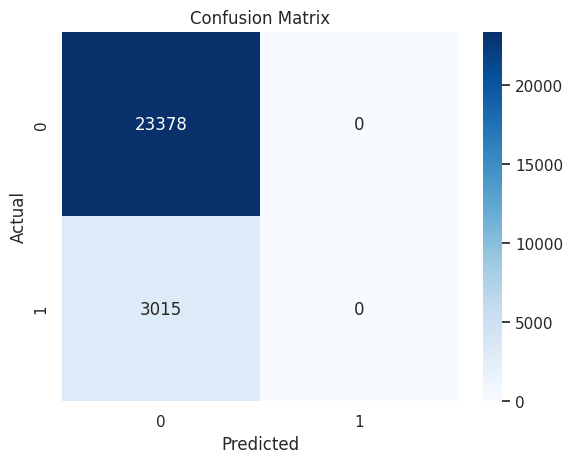

In [25]:
cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipykernel_159/3842372420.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_income = train.groupby('Income_Group')['Risk_Flag'].mean().reset_index()


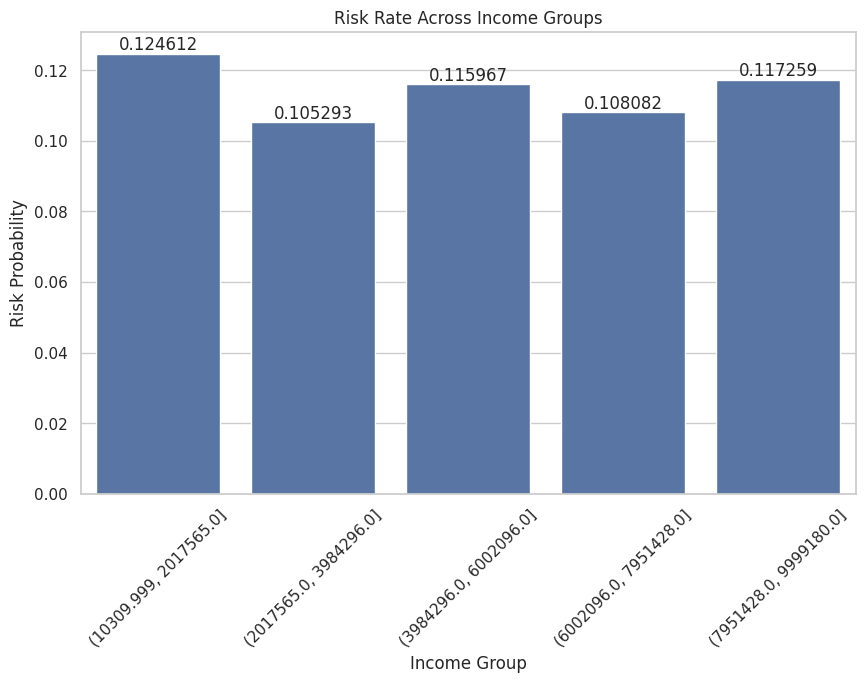

In [29]:
train['Income_Group'] = pd.qcut(train['Income'], 5)

risk_income = train.groupby('Income_Group')['Risk_Flag'].mean().reset_index()

plt.figure(figsize=(10,6))
Chart=sns.barplot(x='Income_Group', y='Risk_Flag', data=risk_income)

plt.title("Risk Rate Across Income Groups")
plt.ylabel("Risk Probability")
plt.xlabel("Income Group")
plt.xticks(rotation=45)
for chart in Chart.containers:
    Chart.bar_label(chart)
plt.show()

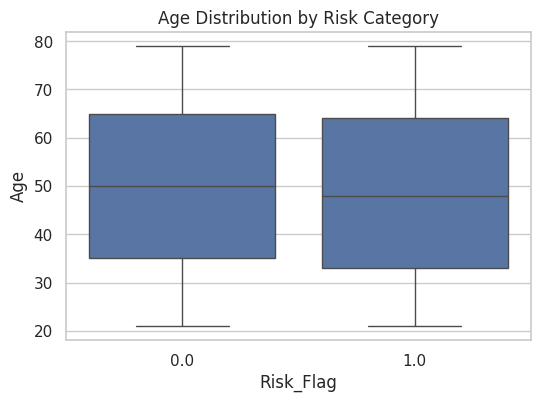

In [30]:
plt.figure(figsize=(6,4))

sns.boxplot(x='Risk_Flag', y='Age', data=train)

plt.title("Age Distribution by Risk Category")

plt.show()

/tmp/ipykernel_159/1163422458.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


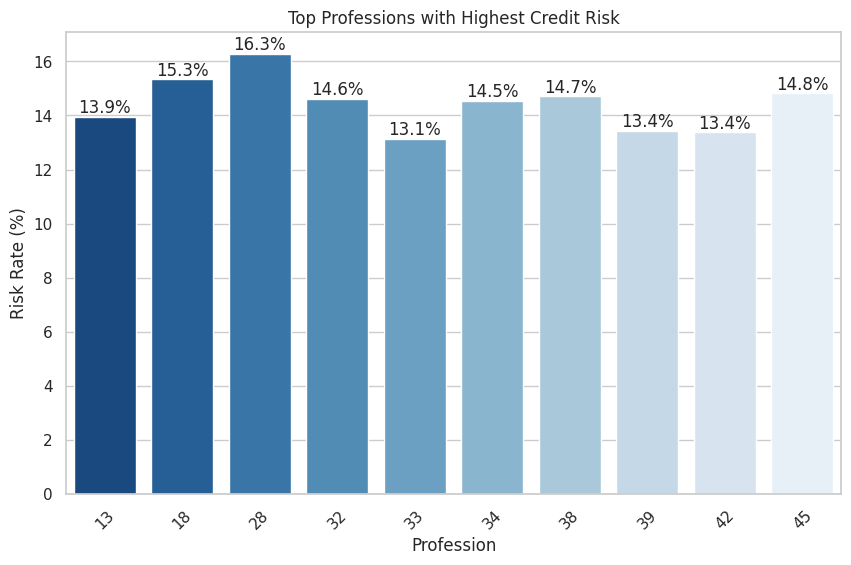

In [41]:
# Calculate risk by profession
profession_risk = train.groupby('Profession')['Risk_Flag'].mean().sort_values(ascending=False).head(10)

# convert to percentage
profession_risk = profession_risk * 100

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=profession_risk.index,
    y=profession_risk.values,
    palette="Blues_r"
)

plt.title("Top Professions with Highest Credit Risk")
plt.xlabel("Profession")
plt.ylabel("Risk Rate (%)")

plt.xticks(rotation=45)

# data labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

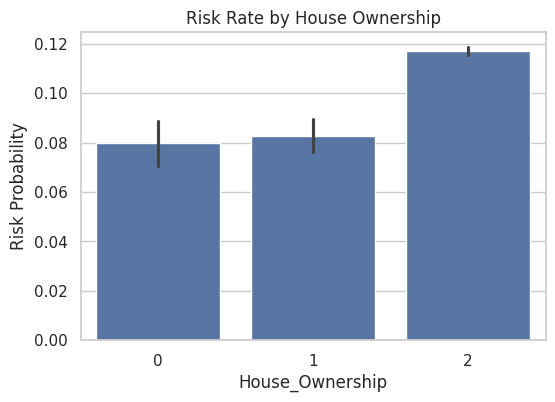

In [42]:
plt.figure(figsize=(6,4))

sns.barplot(x='House_Ownership', y='Risk_Flag', data=train)

plt.title("Risk Rate by House Ownership")

plt.ylabel("Risk Probability")

plt.show()

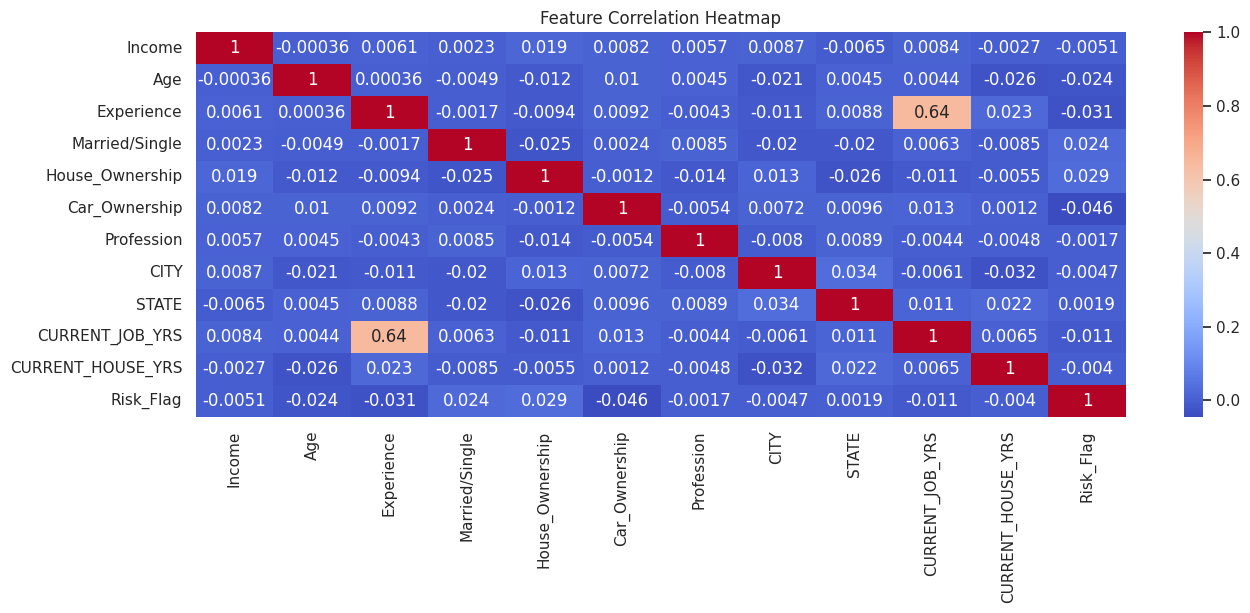

In [46]:
plt.figure(figsize=(15,5))

sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

##FInal Conclusion
This project demonstrated how machine learning models can help financial
institutions identify high-risk loan applicants. Logistic regression
provided a baseline model for classification, while feature importance
analysis helped identify key factors influencing risk prediction.